In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import seaborn as sns
from matplotlib.collections import PolyCollection

In [44]:
colors = ['#1C7ED6', '#77DD77', '#FFB347', '#FF6961', '#17BECF', '#F4D35E']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)
plt.rcParams.update({'font.size': 14})
if not os.path.exists("figs"):
    os.makedirs("figs")

# Homology Split vs Random Split — Correlation & R² Comparison

Violin plots comparing **kendall's τ, Spearman, Pearson** and **R²** distributions across:
- **Homology split** (`full.csv`) — train/test split by sequence homology
- **Random split** (`rnd_split.csv`) — train/test split randomly

Performances are aggregated across **Linear** and **Antimicrobial-Peptides**.
> `AMP_regression_EC_SA` is excluded from this comparison — its results directory does not contain `rnd_split.csv`.

In [45]:
# Aggregate full.csv (homology split) and rnd_split.csv (random split) across models
# AMP_regression_EC_SA has no rnd_split.csv and is excluded for a fair comparison
all_homology = pd.concat([
    pd.read_csv('Linear/results/full.csv', index_col=0),
    pd.read_csv('Antimicrobial-Peptides/results/full.csv', index_col=0),
    pd.read_csv('AMP_regression_EC_SA/results/full.csv', index_col=0),
]).reset_index(drop=True)

all_random = pd.concat([
    pd.read_csv('Linear/results/rnd_split.csv', index_col=0),
    pd.read_csv('Antimicrobial-Peptides/results/rnd_split.csv', index_col=0),
        pd.read_csv('AMP_regression_EC_SA/results/rnd_split.csv', index_col=0),
]).reset_index(drop=True)

print("Homology split rows:", len(all_homology), "| Random split rows:", len(all_random))
all_random.head(3)

Homology split rows: 15 | Random split rows: 3


,property,n,rmse,mse,mae,r2,spearman,kendalls_tau,pearson
0,Escherichia coli,1003,0.731040,0.534420,0.541257,0.199995,0.566792,0.411406,0.589220
1,Escherichia coli,681,0.594420,0.353335,0.453969,0.408943,0.663679,0.485879,0.695144
2,Escherichia coli,606,0.585971,0.343362,0.446760,0.489135,0.691386,0.511225,0.715702


## Violin Plot — Correlation Metrics & R²

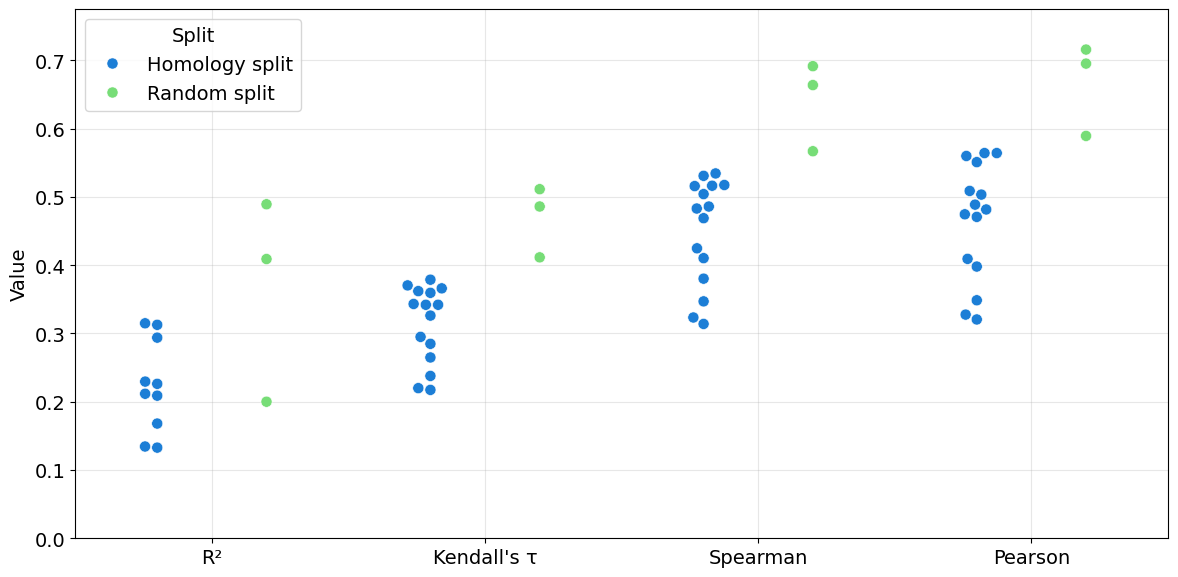

In [47]:
def plot_violin_homology_vs_random(metrics, alias=None):
    """
    Swarm plot comparing metric distributions between the homology split (full.csv)
    and the random split (rnd_split.csv), aggregated across all models that provide both files.

    Args:
        metrics: list of column names to compare.
        alias:   optional list of display labels (same length as metrics).
    Returns:
        fig, ax
    """
    split_datasets = {
        'Homology split': all_homology,
        'Random split':   all_random,
    }

    # Build long-form dataframe
    rows = []
    for metric in metrics:
        for split_name, df in split_datasets.items():
            for value in df[metric]:
                rows.append({'Metric': metric, 'Value': value, 'Split': split_name})
    df_long = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.swarmplot(
        x='Metric', y='Value', hue='Split', data=df_long,
        ax=ax, dodge=True, size=8, linewidth=0.4, edgecolor='white',
    )

    labels = alias or metrics
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


plot_violin_homology_vs_random(
    metrics=['r2', 'kendalls_tau', 'spearman', 'pearson'],
    alias=['R²', "Kendall's τ", 'Spearman', 'Pearson']
)
plt.savefig('figs/homology_vs_random.svg')
plt.savefig('figs/homology_vs_random.pdf')